# Final evaluation

The locked specification is refitted on the combined training and validation
cohorts, then evaluated on the held-out test set. The test set is excluded from
all fitting, tuning, feature selection, validation comparison, and model selection.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import (
    DAYS_AFTER, FEATURE_DISPLAY_NAMES, LANDMARK, N_BOOTSTRAP, SEED,
)
from src.data import create_fixed_split, load_support2
from src.evaluation import (
    EVENT_NAMES, bootstrap_metrics, build_observed_event_matrix,
    calibration_parameters, population_baseline, score_exit_probabilities,
    smooth_calibration,
)
from src.modelling import fit_candidate, predict_candidate

FIGURES = PROJECT_ROOT / 'results' / 'figures'
TABLES = PROJECT_ROOT / 'results' / 'tables'
DEVELOPMENT = PROJECT_ROOT / 'results' / 'development'
BOOTSTRAP = PROJECT_ROOT / 'results' / 'bootstrap'
for directory in (FIGURES, TABLES, BOOTSTRAP):
    directory.mkdir(parents=True, exist_ok=True)
with (DEVELOPMENT / 'locked_model.json').open() as file:
    LOCKED = json.load(file)

## Locked final model

The table records the complete specification selected in notebook 04. No
element of this specification is modified using test results.

In [2]:
display(pd.DataFrame({
    'Item': ['Model family', 'Original feature count', 'Primary metric',
             'Prediction horizons'],
    'Value': [
        LOCKED['model_family'], len(LOCKED['features']),
        LOCKED['selection_metric'], '7, 14, 30, 60, and 90 days',
    ],
}))
display(pd.DataFrame({
    'Feature': [FEATURE_DISPLAY_NAMES[name] for name in LOCKED['features']]
}))
display(pd.DataFrame(
    list(LOCKED['parameters'].items()), columns=['Parameter', 'Value']
))

,Item,Value
0,Model family,Histogram gradient boosting
1,Original feature count,15
2,Primary metric,Mean daily Brier over days 1-90
3,Prediction horizons,"7, 14, 30, 60, and 90 days"


,Feature
0,Patient-reported ADL
1,Diagnosis group
2,Hospital day at study entry
3,Diagnosis class
4,Surrogate-reported ADL
5,Bilirubin
6,Age
7,Mean arterial pressure
8,Creatinine
9,Blood urea nitrogen


,Parameter,Value
0,l2_regularization,10.00
1,learning_rate,0.05
2,max_iter,200.00
3,max_leaf_nodes,15.00
4,min_samples_leaf,50.00


## Final performance

Mean daily Brier evaluates probability error across the complete 90-day path.
Horizon-specific Brier evaluates probability accuracy at selected days, while
AUC evaluates ranking. The direct discrete-time Aalen–Johansen reference assigns
the same population trajectory to every patient.

In [3]:
df = load_support2()
train_df, validation_df, test_df = create_fixed_split(df)
development = pd.concat([train_df, validation_df]).sort_values('patient_id')
development = development.loc[
    development['days_to_hospital_exit'] > LANDMARK
].set_index('patient_id').copy()
test_model = test_df.loc[
    test_df['days_to_hospital_exit'] > LANDMARK
].set_index('patient_id').copy()
for cohort in (development, test_model):
    cohort['event'] = np.where(cohort['in_hospital_death'].eq(1), 2, 1)
assert set(development.index).isdisjoint(test_model.index)

preprocessor, final_model = fit_candidate(
    development, LOCKED['features'], LOCKED['model_family'], LOCKED['parameters'],
    indicator_features=LOCKED['indicator_features'],
)
test_probabilities = predict_candidate(
    preprocessor, final_model, test_model, LOCKED['features'], LOCKED['model_family'],
)
baseline_probabilities = population_baseline(
    development[['days_to_hospital_exit', 'event']], len(test_model)
)
test_metrics, test_score = score_exit_probabilities(test_probabilities, test_model)
baseline_metrics, baseline_score = score_exit_probabilities(
    baseline_probabilities, test_model
)
final_metrics = pd.concat([
    test_metrics.assign(model=LOCKED['model_family']),
    baseline_metrics.assign(model='Population baseline'),
], ignore_index=True)
display(final_metrics.loc[
    final_metrics['metric'].eq('Mean daily Brier')
].pivot(index='event', columns='model', values='value').round(4))
display(final_metrics.loc[
    final_metrics['metric'].isin(['Brier', 'AUC'])
].pivot(index=['event', 'horizon', 'metric'], columns='model', values='value').round(4))
final_metrics.to_csv(TABLES / 'final_test_metrics.csv', index=False)

model,Histogram gradient boosting,Population baseline
event,,
In-hospital death,0.1343,0.173
Live discharge,0.1503,0.216


model                             Histogram gradient boosting  \
event             horizon metric                                
In-hospital death 7       AUC                          0.8226   
                          Brier                        0.0896   
                  14      AUC                          0.8164   
                          Brier                        0.1226   
                  30      AUC                          0.8196   
                          Brier                        0.1381   
                  60      AUC                          0.8138   
                          Brier                        0.1471   
                  90      AUC                          0.8179   
                          Brier                        0.1473   
Live discharge    7       AUC                          0.8346   
                          Brier                        0.1538   
                  14      AUC                          0.8422   
                          Brier                        0.1607   
                  30      AUC                          0.8476   
                          Brier                        0.1545   
                  60      AUC                          0.8301   
                          Brier                        0.1529   
                  90      AUC                          0.8270   
                          Brier                        0.1511   

model                             Population baseline  
event             horizon metric                       
In-hospital death 7       AUC                  0.5000  
                          Brier                0.1077  
                  14      AUC                  0.5000  
                          Brier                0.1543  
                  30      AUC                  0.5000  
                          Brier                0.1787  
                  60      AUC                  0.5000  
                          Brier                0.1904  
                  90      AUC                  0.5000  
                          Brier                0.1930  
Live discharge    7       AUC                  0.5000  
                          Brier                0.2203  
                  14      AUC                  0.5000  
                          Brier                0.2499  
                  30      AUC                  0.5000  
                          Brier                0.2339  
                  60      AUC                  0.5000  
                          Brier                0.2113  
                  90      AUC                  0.5000  
                          Brier                0.2051

The final model has mean daily Brier 0.15026 for live discharge and 0.13433
for in-hospital death, compared with 0.21598 and 0.17298 for the population
reference. Horizon AUC ranges from 0.827 to 0.848 for discharge and from 0.814
to 0.823 for in-hospital death.

## Patient-level bootstrap uncertainty

Two thousand paired resamples keep every patient’s full trajectory and outcome
together. Model and reference predictions use identical resampled patients.
Intervals quantify test-sample uncertainty conditional on the locked fitted
pipeline. Invalid AUC draws are retained as missing values and counted.

In [4]:
bootstrap_distribution, bootstrap_comparisons = bootstrap_metrics(
    test_probabilities, baseline_probabilities, test_model,
    n_bootstrap=N_BOOTSTRAP, seed=SEED,
)
bootstrap_distribution.to_csv(
    BOOTSTRAP / 'metric_distributions.csv.gz', index=False, compression='gzip'
)
bootstrap_comparisons.to_csv(
    BOOTSTRAP / 'paired_brier_comparisons.csv.gz', index=False, compression='gzip'
)

point_metrics = pd.concat([
    test_metrics.assign(model='Final model'),
    baseline_metrics.assign(model='Population baseline'),
], ignore_index=True)
bootstrap_summary = (
    bootstrap_distribution.groupby(['model', 'event', 'metric', 'horizon'])['value']
    .agg(
        Lower=lambda values: values.quantile(0.025),
        Upper=lambda values: values.quantile(0.975),
        Valid='count',
    ).reset_index()
    .merge(
        point_metrics.rename(columns={'value': 'Estimate'}),
        on=['model', 'event', 'metric', 'horizon'],
        how='left',
    )
)
bootstrap_summary['Invalid'] = N_BOOTSTRAP - bootstrap_summary['Valid']
comparison_summary = bootstrap_comparisons.groupby('event').agg(
    Difference_lower=('absolute_difference', lambda values: values.quantile(0.025)),
    Difference_upper=('absolute_difference', lambda values: values.quantile(0.975)),
    Relative_lower=('relative_reduction', lambda values: values.quantile(0.025)),
    Relative_upper=('relative_reduction', lambda values: values.quantile(0.975)),
)
point_comparisons = []
for event_name in EVENT_NAMES:
    model_value = test_metrics.loc[
        test_metrics['event'].eq(event_name)
        & test_metrics['metric'].eq('Mean daily Brier'), 'value'
    ].iloc[0]
    baseline_value = baseline_metrics.loc[
        baseline_metrics['event'].eq(event_name)
        & baseline_metrics['metric'].eq('Mean daily Brier'), 'value'
    ].iloc[0]
    point_comparisons.append({
        'event': event_name,
        'Difference': model_value - baseline_value,
        'Relative_reduction': (baseline_value - model_value) / baseline_value,
    })
comparison_summary = pd.DataFrame(point_comparisons).set_index('event').join(
    comparison_summary
)
display(bootstrap_summary.loc[
    bootstrap_summary['metric'].eq('Mean daily Brier')
].round(4))
display(comparison_summary.round(4))
bootstrap_summary.to_csv(TABLES / 'bootstrap_metric_summary.csv', index=False)
comparison_summary.to_csv(TABLES / 'paired_brier_summary.csv')

,model,event,metric,horizon,Lower,Upper,Valid,Estimate,Invalid
10,Final model,In-hospital death,Mean daily Brier,1-90,0.1246,0.1448,2000,0.1343,0
21,Final model,Live discharge,Mean daily Brier,1-90,0.1419,0.1591,2000,0.1503,0
32,Population baseline,In-hospital death,Mean daily Brier,1-90,0.1612,0.1852,2000,0.1730,0
43,Population baseline,Live discharge,Mean daily Brier,1-90,0.2084,0.2240,2000,0.2160,0


,Difference,Relative_reduction,Difference_lower,Difference_upper,Relative_lower,Relative_upper
event,,,,,,
Live discharge,-0.0657,0.3043,-0.0747,-0.0570,0.2664,0.3409
In-hospital death,-0.0387,0.2234,-0.0477,-0.0299,0.1788,0.2672


The paired intervals exclude zero for both outcomes. Mean daily Brier is lower
than the population reference by 0.06572 for live discharge
(95% CI 0.05698–0.07465 in absolute improvement) and by 0.03865 for
in-hospital death (95% CI 0.02995–0.04775). Relative reductions are 30.4% and
22.3%, respectively.

## Calibration at 30 days

For each outcome, the binary target indicates whether that event occurred by
day 30; the competing event is a non-event for that target. Calibration-in-the-
large detects systematic over- or underprediction, and slope detects predictions
that are too extreme or too weak. The smooth curve is descriptive and does not
recalibrate final predictions.

,Calibration_in_large,CIL_lower,CIL_upper,Calibration_intercept,Intercept_lower,Intercept_upper,Slope,Slope_lower,Slope_upper
event,,,,,,,,,
In-hospital death,0.092,-0.062,0.244,0.076,-0.119,0.301,0.984,0.865,1.124
Live discharge,-0.287,-0.426,-0.139,-0.299,-0.459,-0.138,1.021,0.916,1.145


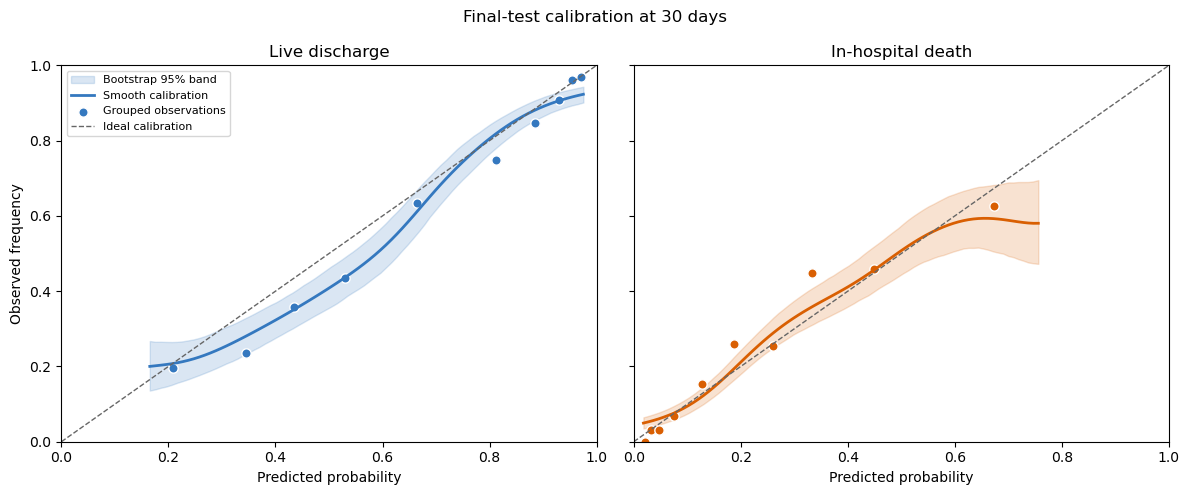

In [5]:
day30_index = 29
observed_30 = build_observed_event_matrix(test_model)[:, day30_index, :]
generator = np.random.default_rng(SEED + 1)
calibration_rows = []
calibration_point_rows = []
curve_rows = []
grouped_frames = []

for event_index, event_name in enumerate(EVENT_NAMES):
    predicted = test_probabilities[:, day30_index, event_index]
    observed = observed_30[:, event_index]
    lower, upper = np.quantile(predicted, [0.02, 0.98])
    grid = np.linspace(lower, upper, 80)
    original_curve = smooth_calibration(predicted, observed, grid)
    cil, intercept, slope = calibration_parameters(predicted, observed)
    calibration_point_rows.append({
        'event': event_name,
        'Calibration_in_large': cil,
        'Calibration_intercept': intercept,
        'Slope': slope,
    })
    calibration = pd.DataFrame({'predicted': predicted, 'observed': observed})
    calibration['group'] = pd.qcut(calibration['predicted'], 10, duplicates='drop')
    grouped = calibration.groupby('group', observed=True).agg(
        predicted=('predicted', 'mean'), observed=('observed', 'mean'),
        patients=('observed', 'size'),
    ).reset_index(drop=True)
    grouped['event'] = event_name
    grouped_frames.append(grouped)

    bootstrap_curves = []
    for replicate in range(1, N_BOOTSTRAP + 1):
        positions = generator.integers(0, len(observed), len(observed))
        cil, intercept, slope = calibration_parameters(
            predicted[positions], observed[positions]
        )
        calibration_rows.append({
            'event': event_name, 'replicate': replicate,
            'calibration_in_large': cil,
            'calibration_intercept': intercept,
            'calibration_slope': slope,
        })
        bootstrap_curves.append(smooth_calibration(
            predicted[positions], observed[positions], grid
        ))
    bootstrap_curves = np.asarray(bootstrap_curves)
    for position, probability in enumerate(grid):
        curve_rows.append({
            'event': event_name, 'predicted': probability,
            'smooth': original_curve[position],
            'lower': np.nanquantile(bootstrap_curves[:, position], 0.025),
            'upper': np.nanquantile(bootstrap_curves[:, position], 0.975),
        })

calibration_distribution = pd.DataFrame(calibration_rows)
calibration_curves = pd.DataFrame(curve_rows)
calibration_groups = pd.concat(grouped_frames, ignore_index=True)
calibration_summary = calibration_distribution.groupby('event').agg(
    CIL_lower=('calibration_in_large', lambda values: values.quantile(0.025)),
    CIL_upper=('calibration_in_large', lambda values: values.quantile(0.975)),
    Intercept_lower=('calibration_intercept', lambda values: values.quantile(0.025)),
    Intercept_upper=('calibration_intercept', lambda values: values.quantile(0.975)),
    Slope_lower=('calibration_slope', lambda values: values.quantile(0.025)),
    Slope_upper=('calibration_slope', lambda values: values.quantile(0.975)),
).join(pd.DataFrame(calibration_point_rows).set_index('event'))
calibration_summary = calibration_summary[[
    'Calibration_in_large', 'CIL_lower', 'CIL_upper',
    'Calibration_intercept', 'Intercept_lower', 'Intercept_upper',
    'Slope', 'Slope_lower', 'Slope_upper',
]]
display(calibration_summary.round(3))
calibration_distribution.to_csv(
    BOOTSTRAP / 'calibration_parameter_distributions.csv.gz',
    index=False, compression='gzip',
)
calibration_curves.to_csv(TABLES / 'calibration_curves.csv', index=False)
calibration_groups.to_csv(TABLES / 'calibration_groups.csv', index=False)
calibration_summary.to_csv(TABLES / 'calibration_summary.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, event_name, colour in zip(
    axes, EVENT_NAMES, ['#3478bf', '#d95f02']
):
    curve = calibration_curves.loc[calibration_curves['event'].eq(event_name)]
    groups = calibration_groups.loc[calibration_groups['event'].eq(event_name)]
    ax.fill_between(curve['predicted'], curve['lower'], curve['upper'],
                    color=colour, alpha=0.18, label='Bootstrap 95% band')
    ax.plot(curve['predicted'], curve['smooth'], color=colour, linewidth=2,
            label='Smooth calibration')
    ax.scatter(groups['predicted'], groups['observed'], color=colour,
               edgecolor='white', s=45, label='Grouped observations')
    ax.plot([0, 1], [0, 1], '--', color='#666666', linewidth=1,
            label='Ideal calibration')
    ax.set(title=event_name, xlabel='Predicted probability',
           xlim=(0, 1), ylim=(0, 1))
axes[0].set_ylabel('Observed frequency')
axes[0].legend(fontsize=8)
fig.suptitle('Final-test calibration at 30 days')
fig.tight_layout()
fig.savefig(FIGURES / 'final_test_calibration.png', dpi=160, bbox_inches='tight')
plt.show()

At 30 days, calibration slope is 1.02 for live discharge and 0.99 for
in-hospital death, both close to the ideal value of one. Calibration-in-the-
large is −0.29 for discharge, indicating average overprediction, and 0.09 for
death. Curves are most reliable where predictions are common; sparse extremes
should not be overinterpreted.

## How predicted outcomes evolve over time

Metrics describe accuracy; trajectories show the probability paths produced by
the model. Probability mass moves from continued hospitalisation into the two
mutually exclusive terminal outcomes.

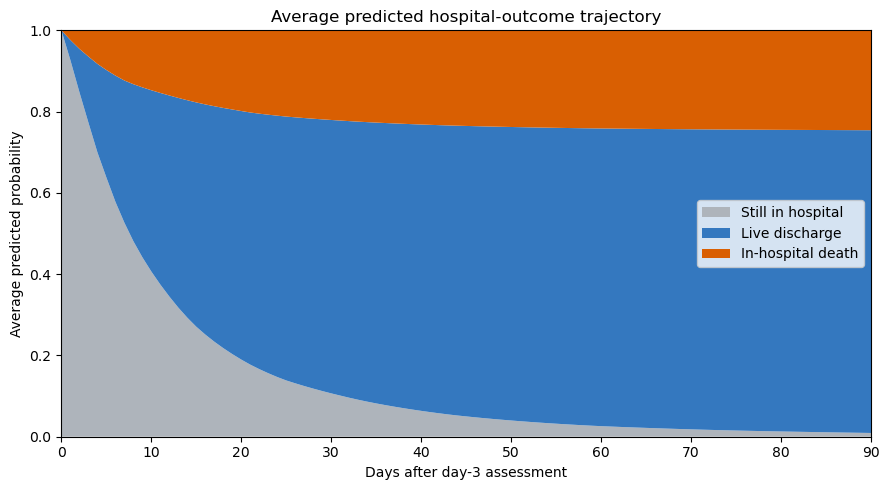

In [6]:
trajectory_days = np.arange(0, 91)
stay = np.clip(1 - test_probabilities.sum(axis=2), 0, 1)
states = np.stack([stay, test_probabilities[:, :, 0], test_probabilities[:, :, 1]], axis=2)
initial = np.zeros((len(test_model), 1, 3))
initial[:, 0, 0] = 1
states = np.concatenate([initial, states], axis=1)
assert np.allclose(states.sum(axis=2), 1, atol=1e-8)
state_labels = ['Still in hospital', 'Live discharge', 'In-hospital death']
colours = ['#aeb4bb', '#3478bf', '#d95f02']

mean_states = states.mean(axis=0)
fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(trajectory_days, mean_states.T, labels=state_labels, colors=colours)
ax.set(xlim=(0, 90), ylim=(0, 1), xlabel='Days after day-3 assessment',
       ylabel='Average predicted probability',
       title='Average predicted hospital-outcome trajectory')
ax.legend(loc='center right')
fig.tight_layout()
fig.savefig(FIGURES / 'final_test_overall_trajectory.png', dpi=160, bbox_inches='tight')
plt.show()

### Diagnosis-class trajectories

Small multiples show descriptive average predictions for diagnosis classes with
at least 75 test patients. Shared axes support visual comparison; these curves
are not causal effects or subgroup-specific validation.

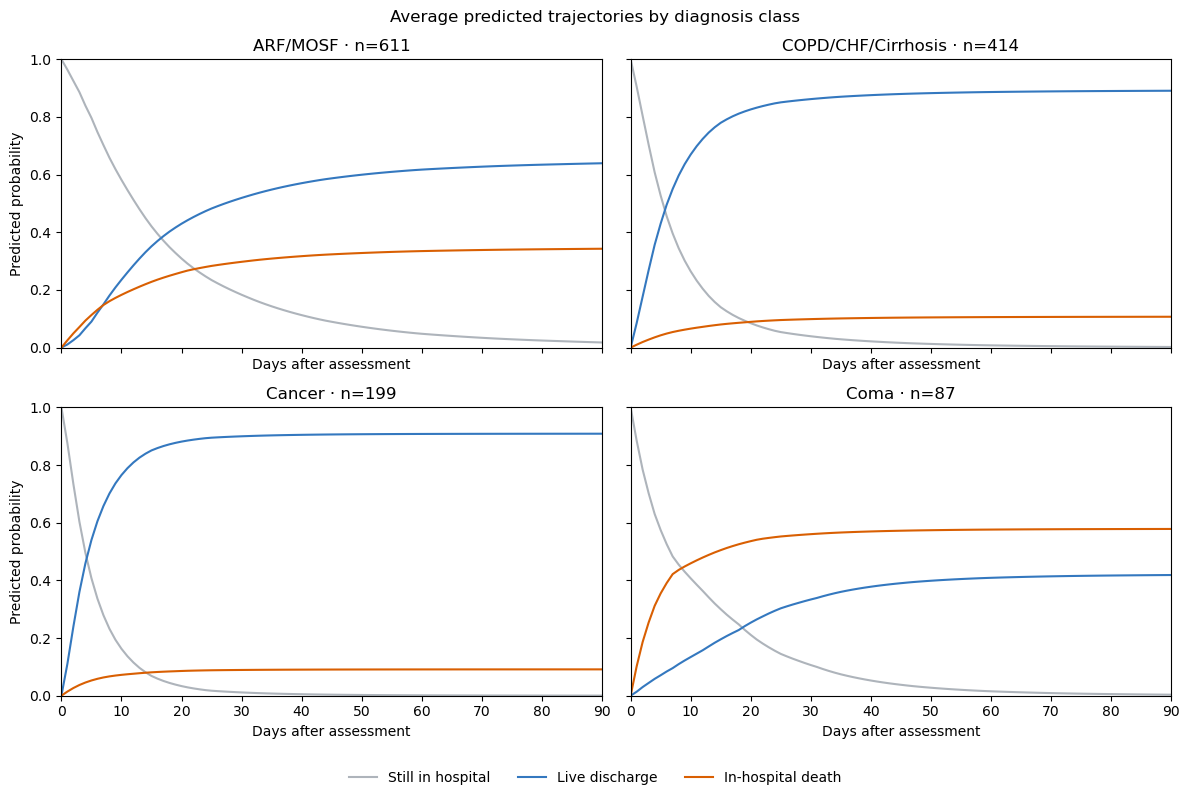

In [7]:
counts = test_model['diagnosis_class'].value_counts(dropna=False)
groups = counts.loc[counts >= 75].head(6).index.tolist()
fig, axes = plt.subplots(
    int(np.ceil(len(groups) / 2)), 2, figsize=(12, 4 * np.ceil(len(groups) / 2)),
    sharex=True, sharey=True, squeeze=False,
)
for panel, (ax, group) in enumerate(zip(axes.ravel(), groups)):
    mask = test_model['diagnosis_class'].eq(group).to_numpy()
    average = states[mask].mean(axis=0)
    for index, (label, colour) in enumerate(zip(state_labels, colours)):
        ax.plot(trajectory_days, average[:, index], color=colour, label=label)
    ax.set(title=f'{group} · n={mask.sum()}', xlim=(0, 90), ylim=(0, 1),
           xlabel='Days after assessment')
    if panel % 2 == 0:
        ax.set_ylabel('Predicted probability')
for ax in axes.ravel()[len(groups):]:
    ax.set_visible(False)
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)
fig.suptitle('Average predicted trajectories by diagnosis class')
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(
    FIGURES / 'final_test_diagnosis_class_trajectories.png',
    dpi=160, bbox_inches='tight',
)
plt.show()

### Representative individual trajectories

Three distinct examples are selected mechanically from predictions: highest
14-day discharge probability, highest 30-day death probability, and highest
30-day continued-hospitalisation probability. Observed outcomes do not determine
selection, and the examples are not clinical recommendations.

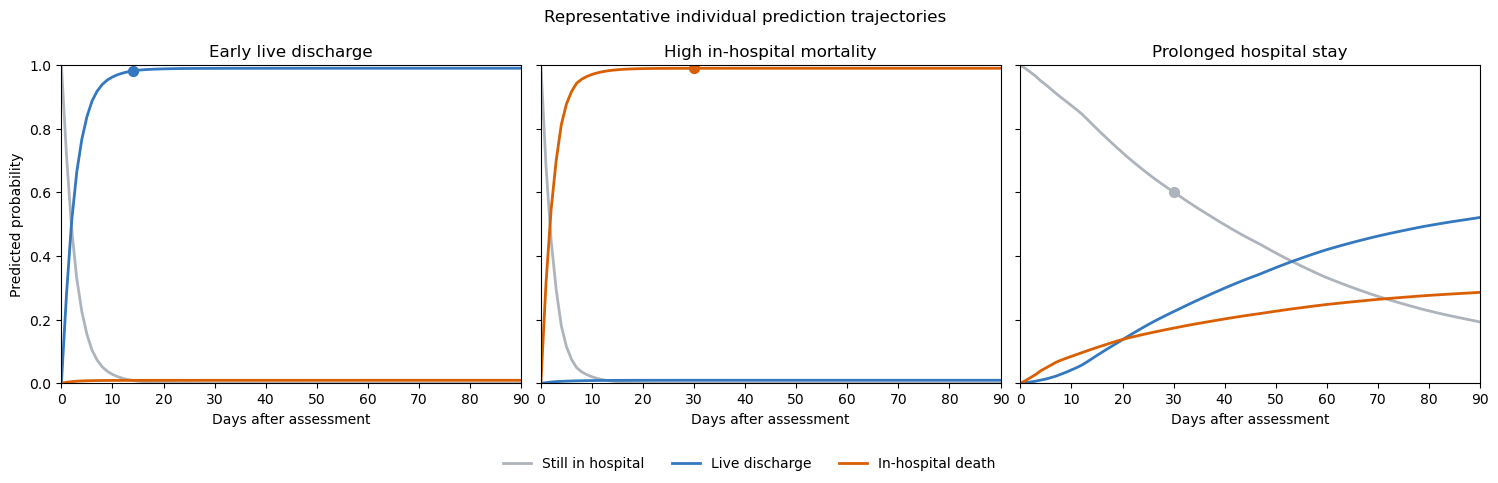

,Age,Sex,Diagnosis group,Comorbidities,Patient-reported ADL
Prediction profile,,,,,
Early live discharge,42.41998,female,COPD,1,0.0
High in-hospital mortality,45.56598,male,MOSF w/Malig,3,NaN
Prolonged hospital stay,52.91199,male,ARF/MOSF w/Sepsis,2,NaN


In [8]:
profile_specs = [
    ('Early live discharge', states[:, 14, 1], 1, 14),
    ('High in-hospital mortality', states[:, 30, 2], 2, 30),
    ('Prolonged hospital stay', states[:, 30, 0], 0, 30),
]
selected = []
for _, scores, _, _ in profile_specs:
    selected.append(next(
        int(position) for position in np.argsort(-scores, kind='stable')
        if int(position) not in selected
    ))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for ax, (name, _, state_index, day), position in zip(axes, profile_specs, selected):
    for index, (label, colour) in enumerate(zip(state_labels, colours)):
        ax.plot(trajectory_days, states[position, :, index],
                color=colour, linewidth=2, label=label)
    ax.scatter(day, states[position, day, state_index],
               color=colours[state_index], s=50)
    ax.set(title=name, xlim=(0, 90), ylim=(0, 1),
           xlabel='Days after assessment')
axes[0].set_ylabel('Predicted probability')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)
fig.suptitle('Representative individual prediction trajectories')
fig.tight_layout(rect=(0, 0.08, 1, 1))
fig.savefig(
    FIGURES / 'final_test_individual_trajectories.png',
    dpi=160, bbox_inches='tight',
)
plt.show()

context = []
for (name, _, _, _), position in zip(profile_specs, selected):
    patient = test_model.iloc[position]
    context.append({
        'Prediction profile': name, 'Age': patient['age'],
        'Sex': patient['sex'], 'Diagnosis group': patient['diagnosis_group'],
        'Comorbidities': patient['number_of_comorbidities'],
        'Patient-reported ADL': patient['adl_patient_reported'],
    })
display(pd.DataFrame(context).set_index('Prediction profile'))

## Scope

The subgroup trajectories are averages of model predictions, and the individual
paths are illustrative examples. Neither supports causal inference, replaces
formal subgroup validation, or provides a clinical recommendation. Evaluation
within one historical dataset also does not establish contemporary external
validity.